# Chapter 7 Companion — Quantum Hardware

Runnable companions to the worked examples in
[`docs/07_quantum_hardware`](../docs/07_quantum_hardware):

- [`01_superconducting_qubits.md`](../docs/07_quantum_hardware/01_superconducting_qubits.md)
- [`04_benchmarking_and_characterization.md`](../docs/07_quantum_hardware/04_benchmarking_and_characterization.md)

(For simulated T₁/Ramsey/RB experiments with Aer noise models, see
[`noise_labs.ipynb`](noise_labs.ipynb) — this notebook reproduces the docs' analytical numbers
and fits.)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

np.set_printoptions(precision=6, suppress=True)

h    = 6.62607015e-34     # J s
hbar = 1.054571817e-34    # J s
e    = 1.602176634e-19    # C
kB   = 1.380649e-23       # J/K

## Example 1 — Transmon design parameters

*Docs: `01_superconducting_qubits.md`, "Worked Example" + Exercise 1.* Designing a transmon
from `ω₀₁ ≈ √(8 E_J E_C)/ℏ` and `α ≈ −E_C/ℏ`:

| spec | `E_J/h` | `E_J/E_C` | `C` | `I_c` |
|------|--------|-----------|-----|-------|
| 5 GHz, −200 MHz | 15.6 GHz | 78 | ≈ 97 fF | ≈ 31 nA |
| 4.5 GHz, −250 MHz | 10.13 GHz | 40.5 | ≈ 77 fF | ≈ 20 nA |

In [2]:
def transmon_design(f01_GHz, alpha_MHz):
    E_C = h * alpha_MHz * 1e6                     # E_C/h = |alpha|
    E_J = (hbar * 2*np.pi * f01_GHz * 1e9)**2 / (8 * E_C)
    C   = e**2 / (2 * E_C)
    I_c = 2 * e * E_J / hbar
    return dict(EJ_over_h_GHz=E_J / h / 1e9, ratio=E_J / E_C,
                C_fF=C * 1e15, Ic_nA=I_c * 1e9)

for f01, alpha, doc in [(5.0, 200, (15.6, 78, 97, 31)),
                        (4.5, 250, (10.13, 40.5, 77, 20))]:
    d = transmon_design(f01, alpha)
    print(f"spec {f01} GHz / -{alpha} MHz:  E_J/h = {d['EJ_over_h_GHz']:.2f} GHz, "
          f"E_J/E_C = {d['ratio']:.1f}, C = {d['C_fF']:.0f} fF, I_c = {d['Ic_nA']:.0f} nA")
    print(f"   docs:                E_J/h = {doc[0]} GHz, E_J/E_C = {doc[1]}, "
          f"C ≈ {doc[2]} fF, I_c ≈ {doc[3]} nA")
    assert np.isclose(d["EJ_over_h_GHz"], doc[0], rtol=0.02)
    assert np.isclose(d["ratio"], doc[1], rtol=0.02)
    assert np.isclose(d["C_fF"], doc[2], rtol=0.05)
    assert np.isclose(d["Ic_nA"], doc[3], rtol=0.06)

# Exercise 2: thermal occupation of a 4.5 GHz qubit at 20 mK
ratio = h * 4.5e9 / (kB * 0.020)
n_th = 1 / (np.exp(ratio) - 1)
print(f"\nℏω/k_BT = {ratio:.1f} (docs: 10.8);  n_th = {n_th:.1e} (docs: ≈ 2e-5)")
assert np.isclose(ratio, 10.8, atol=0.05) and 1.5e-5 < n_th < 2.5e-5
print("thermal |1> population ~0.002% — measured 0.1-1% comes from non-equilibrium noise.")

spec 5.0 GHz / -200 MHz:  E_J/h = 15.62 GHz, E_J/E_C = 78.1, C = 97 fF, I_c = 31 nA
   docs:                E_J/h = 15.6 GHz, E_J/E_C = 78, C ≈ 97 fF, I_c ≈ 31 nA
spec 4.5 GHz / -250 MHz:  E_J/h = 10.12 GHz, E_J/E_C = 40.5, C = 77 fF, I_c = 20 nA
   docs:                E_J/h = 10.13 GHz, E_J/E_C = 40.5, C ≈ 77 fF, I_c ≈ 20 nA

ℏω/k_BT = 10.8 (docs: 10.8);  n_th = 2.0e-05 (docs: ≈ 2e-5)
thermal |1> population ~0.002% — measured 0.1-1% comes from non-equilibrium noise.


## Example 2 — T₁ and Ramsey decay curves

*Docs: `04_benchmarking_and_characterization.md`, "T1 and T2 Measurements" + Exercise 4.*
The characterization fits: `P(1|τ) = A e^{−τ/T₁} + B` (inversion recovery) and
`P(0|τ) = [1 + e^{−τ/T₂*} cos(2πδτ + φ)]/2` (Ramsey). Exercise 4's consistency check:
`T₁ = 25 μs`, `T₂* = 18 μs`, `T₂(echo) = 36 μs` — satisfying `T₂* ≤ T₂ ≤ 2T₁ = 50 μs`.
We synthesize shot-noise-limited data with these parameters and recover them by fitting.

T1 fit: 25.0 us  (true 25 us);  A = 1.000, B = -0.002
Ramsey fit: T2* = 18.0 us (true 18), detuning = 249 kHz (true 250)


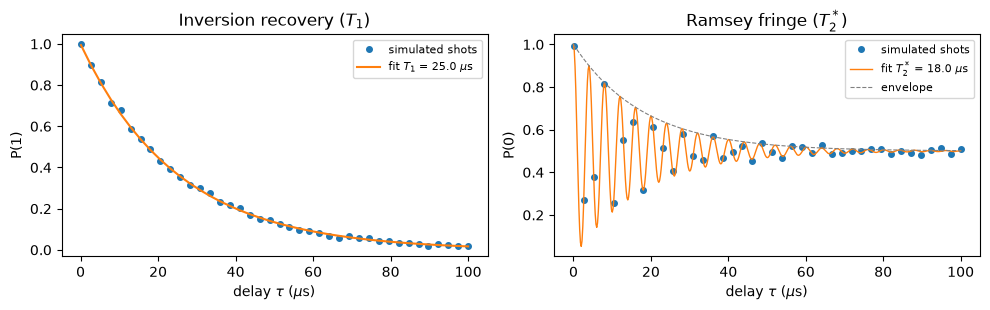

echo T2 = 36.0 us doubles T2* = 18.0 us -> quasi-static noise dominates;
ceiling: T2 <= 2*T1 = 50.0 us


In [3]:
rng = np.random.default_rng(11)
T1_true, T2s_true, T2e_true = 25.0, 18.0, 36.0   # microseconds (docs, Exercise 4)
assert T2s_true <= T2e_true <= 2 * T1_true       # docs consistency ordering

taus = np.linspace(0.1, 100, 40)
shots = 2000

# --- T1: inversion recovery ---
p1_ideal = np.exp(-taus / T1_true)
p1_meas = rng.binomial(shots, np.clip(p1_ideal, 0, 1)) / shots
popt_t1, _ = curve_fit(lambda t, A, T1, B: A*np.exp(-t/T1) + B, taus, p1_meas,
                       p0=[1.0, 20.0, 0.0])
print(f"T1 fit: {popt_t1[1]:.1f} us  (true 25 us);  A = {popt_t1[0]:.3f}, B = {popt_t1[2]:.3f}")
assert abs(popt_t1[1] - T1_true) < 2.0

# --- Ramsey: detuned fringe with T2* envelope ---
delta = 0.25          # MHz -> fringe period 4 us
p0_ideal = 0.5 * (1 + np.exp(-taus / T2s_true) * np.cos(2*np.pi*delta*taus))
p0_meas = rng.binomial(shots, np.clip(p0_ideal, 0, 1)) / shots
popt_rm, _ = curve_fit(
    lambda t, T2, d, phi: 0.5*(1 + np.exp(-t/T2)*np.cos(2*np.pi*d*t + phi)),
    taus, p0_meas, p0=[15.0, 0.24, 0.0])
print(f"Ramsey fit: T2* = {popt_rm[0]:.1f} us (true 18), detuning = {popt_rm[1]*1e3:.0f} kHz (true 250)")
assert abs(popt_rm[0] - T2s_true) < 2.5

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(taus, p1_meas, "o", ms=4, label="simulated shots")
axes[0].plot(taus, popt_t1[0]*np.exp(-taus/popt_t1[1]) + popt_t1[2], "-",
             label=f"fit $T_1$ = {popt_t1[1]:.1f} $\\mu$s")
axes[0].set_xlabel(r"delay $\tau$ ($\mu$s)"); axes[0].set_ylabel("P(1)")
axes[0].set_title("Inversion recovery ($T_1$)"); axes[0].legend(fontsize=8)
axes[1].plot(taus, p0_meas, "o", ms=4, label="simulated shots")
tt = np.linspace(0, 100, 500)
axes[1].plot(tt, 0.5*(1 + np.exp(-tt/popt_rm[0])*np.cos(2*np.pi*popt_rm[1]*tt + popt_rm[2])),
             "-", lw=1, label=f"fit $T_2^*$ = {popt_rm[0]:.1f} $\\mu$s")
axes[1].plot(tt, 0.5*(1 + np.exp(-tt/popt_rm[0])), "--", color="gray", lw=0.8, label="envelope")
axes[1].set_xlabel(r"delay $\tau$ ($\mu$s)"); axes[1].set_ylabel("P(0)")
axes[1].set_title("Ramsey fringe ($T_2^*$)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"echo T2 = {T2e_true} us doubles T2* = {T2s_true} us -> quasi-static noise dominates;")
print(f"ceiling: T2 <= 2*T1 = {2*T1_true} us")

## Example 3 — Randomized-benchmarking analysis of the docs' dataset

*Docs: `04_benchmarking_and_characterization.md`, "Worked Example".* Fitting
`P(0|m) = A pᵐ + B` to the table `{(1,0.977), (10,0.950), (20,0.922), (50,0.848),
(100,0.753), (200,0.633)}` gives `A = 0.480`, `p = 0.9936`, `B = 0.500`, hence
`r = (1−p)/2 = 0.32 %` per Clifford and `≈ 0.17 %` per native gate (1.875 natives/Clifford).
Exercise 1's two-point shortcut (`m = 20, 100` plus the known asymptote) gives `p = 0.99363`.

fit: A = 0.480, p = 0.9936, B = 0.500  (docs: 0.480, 0.9936, 0.500)
error per Clifford r = (1-p)/2 = 0.0032 = 0.32%  (docs: 0.32%)
error per native gate ≈ r/1.875 = 0.17%  (docs: 0.17%)
two-point extraction (m = 20, 100): p = 0.99363  (docs: 0.99363)
A + B = 0.980 -> ~2% combined SPAM error (docs: ~2%)


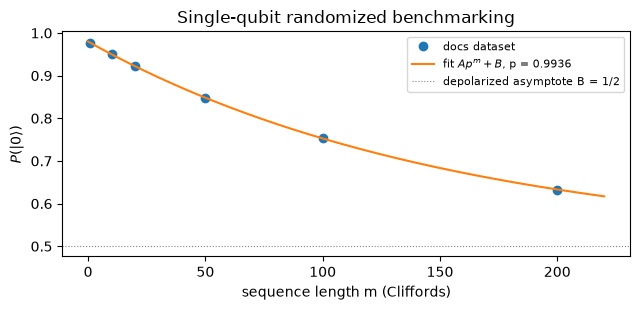

In [4]:
m_data = np.array([1, 10, 20, 50, 100, 200])
P_data = np.array([0.977, 0.950, 0.922, 0.848, 0.753, 0.633])

popt, _ = curve_fit(lambda m, A, p, B: A*p**m + B, m_data, P_data, p0=[0.5, 0.99, 0.5])
A_fit, p_fit, B_fit = popt
r = (1 - p_fit) / 2
print(f"fit: A = {A_fit:.3f}, p = {p_fit:.4f}, B = {B_fit:.3f}  (docs: 0.480, 0.9936, 0.500)")
print(f"error per Clifford r = (1-p)/2 = {r:.4f} = {100*r:.2f}%  (docs: 0.32%)")
print(f"error per native gate ≈ r/1.875 = {100*r/1.875:.2f}%  (docs: 0.17%)")
assert np.isclose(A_fit, 0.480, atol=2e-3)
assert np.isclose(p_fit, 0.9936, atol=2e-4)
assert np.isclose(B_fit, 0.500, atol=2e-3)

# Exercise 1: two-point extraction with known asymptote B = 0.5
p_two = ((P_data[2] - 0.5) / (P_data[4] - 0.5))**(-1/80)
print(f"two-point extraction (m = 20, 100): p = {p_two:.5f}  (docs: 0.99363)")
assert np.isclose(p_two, 0.99363, atol=5e-5)

# SPAM: A + B at m -> 0
print(f"A + B = {A_fit + B_fit:.3f} -> ~{100*(1 - (A_fit + B_fit)):.0f}% combined SPAM error (docs: ~2%)")

mm = np.linspace(0, 220, 300)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(m_data, P_data, "o", label="docs dataset")
ax.plot(mm, A_fit*p_fit**mm + B_fit, "-", label=f"fit $A p^m + B$, p = {p_fit:.4f}")
ax.axhline(0.5, color="gray", ls=":", lw=0.8, label="depolarized asymptote B = 1/2")
ax.set_xlabel("sequence length m (Cliffords)"); ax.set_ylabel(r"$P(|0\rangle)$")
ax.set_title("Single-qubit randomized benchmarking")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## Example 4 — Interleaved RB and the RB error formula

*Docs: `04_benchmarking_and_characterization.md`, Exercise 2 + "Interleaved RB".* With
reference decay `p_ref = 0.9936` and interleaved decay `p_int = 0.9887`, the target-gate
error is `r_G = (1 − p_int/p_ref)(2ⁿ−1)/2ⁿ ≈ 2.5×10⁻³`. We also check the general error
formula `r = (1−p)(2ⁿ−1)/2ⁿ` reduces to `(1−p)/2` for one qubit.

interleaved RB: r_G = (1 - p_int/p_ref)/2 = 2.47e-03  (docs: ≈ 2.5e-3)
single-qubit formula check: r = (1-p)/2 -> 0.0031999999999999806 = 0.0032 ✓


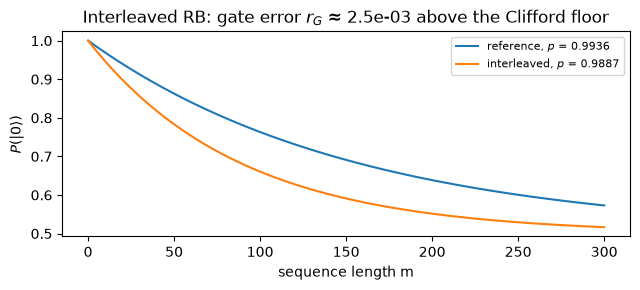

virtual-Z sanity check: p_int/p_ref = 1 gives r_G = 0.0 (docs: r_Z = 0)


In [5]:
def rb_error(p, n_qubits=1):
    d = 2**n_qubits
    return (1 - p) * (d - 1) / d

p_ref, p_int = 0.9936, 0.9887
r_G = rb_error(p_int / p_ref)
print(f"interleaved RB: r_G = (1 - p_int/p_ref)/2 = {r_G:.2e}  (docs: ≈ 2.5e-3)")
assert np.isclose(r_G, 2.5e-3, atol=5e-5)

print("single-qubit formula check: r = (1-p)/2 ->", rb_error(0.9936), "= 0.0032 ✓")
assert np.isclose(rb_error(0.9936), 0.0032)

# what the interleaved decay looks like against the reference
mm = np.linspace(0, 300, 200)
fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(mm, 0.5*p_ref**mm + 0.5, label=f"reference, $p$ = {p_ref}")
ax.plot(mm, 0.5*p_int**mm + 0.5, label=f"interleaved, $p$ = {p_int}")
ax.set_xlabel("sequence length m"); ax.set_ylabel(r"$P(|0\rangle)$")
ax.set_title(f"Interleaved RB: gate error $r_G$ ≈ {r_G:.1e} above the Clifford floor")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("virtual-Z sanity check: p_int/p_ref = 1 gives r_G =", rb_error(1.0), "(docs: r_Z = 0)")